In [1]:
pip install faker

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 21.1 MB/s eta 0:00:00


Dataset Created Successfully!
Customer_ID        0
Age                0
Gender             0
Tenure             0
Balance            0
CreditScore        0
EstimatedSalary    0
NumOfProducts      0
IsActiveMember     0
Churn              0
dtype: int64
Mean:
 Age                    44.000000
Tenure                  4.998630
Balance            100362.258765
CreditScore           599.784670
EstimatedSalary     79958.676852
NumOfProducts           2.502860
IsActiveMember          0.499090
Churn                   0.040310
dtype: float64

Median:
 Age                    44.000
Tenure                  5.000
Balance            100437.865
CreditScore           599.000
EstimatedSalary     80111.755
NumOfProducts           3.000
IsActiveMember          0.000
Churn                   0.000
dtype: float64

Std Dev:
 Age                   15.304576
Tenure                 3.164558
Balance            57829.182399
CreditScore          173.306966
EstimatedSalary    40369.948601
NumOfProducts          1.

/tmp/ipykernel_1277/16823822.py:57: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Churn', data=df, palette='viridis')


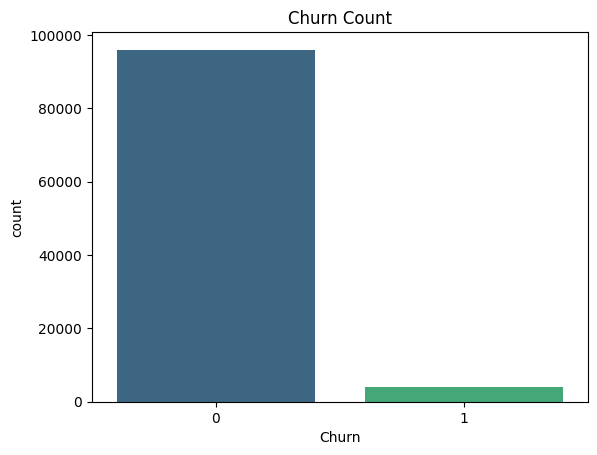

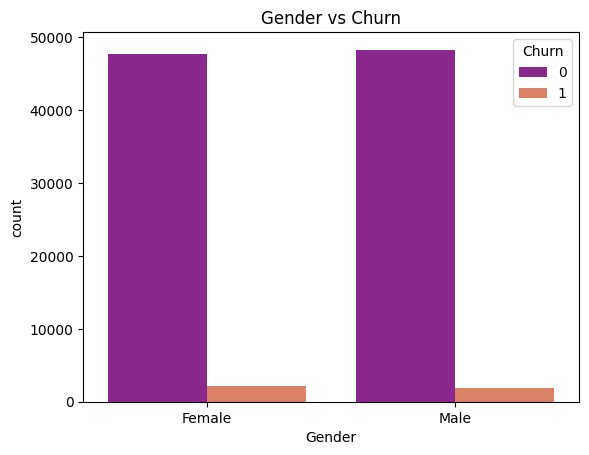

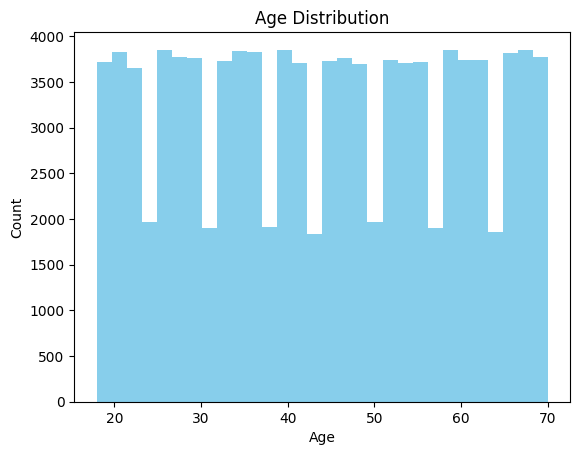

/tmp/ipykernel_1277/16823822.py:68: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y='Balance', data=df, palette='magma')


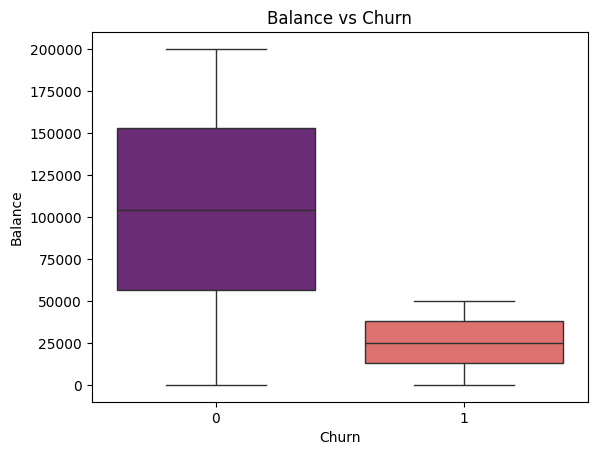

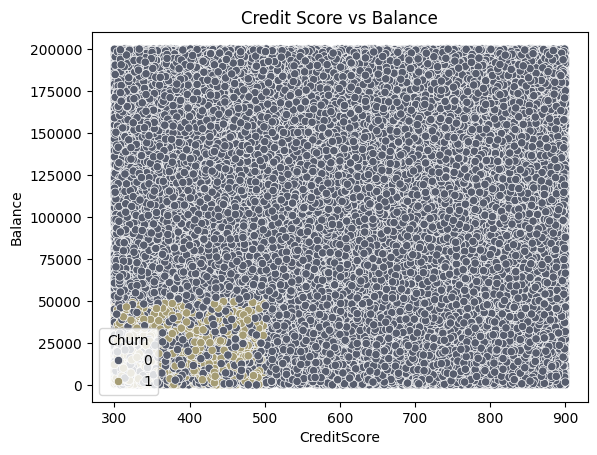

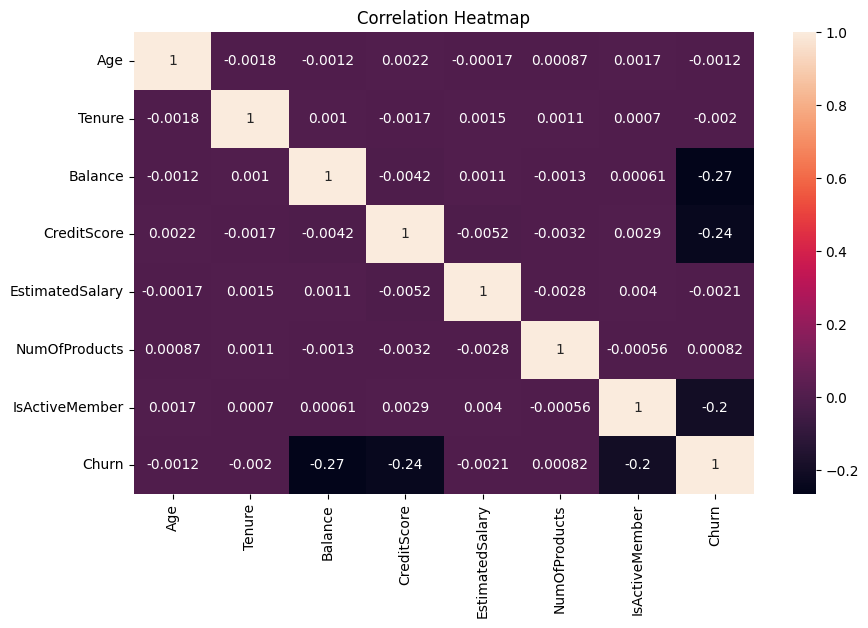

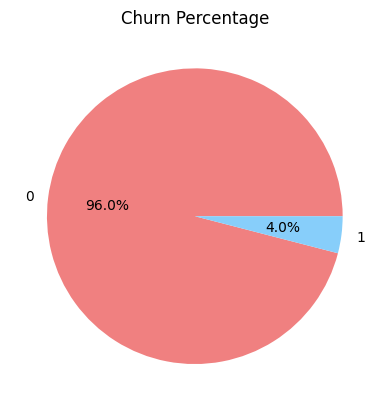

In [3]:
import pandas as pd
import numpy as np
import random
from faker import Faker
import matplotlib.pyplot as plt
import seaborn as sns



fake = Faker()


n = 100000

data = []

for i in range(n):
    age = random.randint(18, 70)
    gender = random.choice(['Male', 'Female'])
    tenure = random.randint(0, 10)
    balance = round(random.uniform(0, 200000), 2)
    credit_score = random.randint(300, 900)
    salary = round(random.uniform(10000, 150000), 2)
    products = random.randint(1, 4)
    active = random.choice([0, 1])


    churn = 1 if (balance < 50000 and active == 0 and credit_score < 500) else 0

    data.append([
        fake.uuid4(), age, gender, tenure, balance,
        credit_score, salary, products, active, churn
    ])

columns = [
    "Customer_ID", "Age", "Gender", "Tenure",
    "Balance", "CreditScore", "EstimatedSalary",
    "NumOfProducts", "IsActiveMember", "Churn"
]

df = pd.DataFrame(data, columns=columns)

df.to_csv("customer_churn_data.csv", index=False)

print("Dataset Created Successfully!")
df.head()

print(df.isnull().sum())

print("Mean:\n", df.mean(numeric_only=True))
print("\nMedian:\n", df.median(numeric_only=True))
print("\nStd Dev:\n", df.std(numeric_only=True))

churn_rate = df['Churn'].value_counts(normalize=True) * 100
print(churn_rate)

sns.countplot(x='Churn', hue='Churn', data=df, palette='viridis', legend=False) # Modified line
plt.title("Churn Count")
plt.show()
sns.countplot(x='Gender', hue='Churn', data=df, palette='plasma')
plt.title("Gender vs Churn")
plt.show()
plt.hist(df['Age'], bins=30, color='skyblue')
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()
sns.boxplot(x='Churn', y='Balance', data=df, palette='magma')
plt.title("Balance vs Churn")
plt.show()
sns.scatterplot(x='CreditScore', y='Balance', hue='Churn', data=df, palette='cividis')
plt.title("Credit Score vs Balance")
plt.show()
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='rocket')
plt.title("Correlation Heatmap")
plt.show()
df['Churn'].value_counts().plot.pie(autopct='%1.1f%%', colors=['lightcoral', 'lightskyblue'])
plt.title("Churn Percentage")
plt.ylabel("")
plt.show()